# 01 — Map Projections & Distortion Analysis
**Part 1 of 7** | GeoMetric Project

## Learning Objectives
- Understand that projection is a scientific choice, not cosmetic
- Compare Albers Equal-Area, Lambert Conformal Conic, and Winkel Tripel
- Identify which projection is appropriate for which task

## Key Concept
Every flat map of the Earth distorts *something*. The question is: what are you willing to sacrifice?

In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import warnings; warnings.filterwarnings("ignore")
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
from scripts.utils.config import PATHS, PROJECTIONS, PROJECTION_LABELS, STYLE
from scripts.utils.map_utils import reproject_gdf, add_map_annotations, save_figure, projection_comparison_table

In [2]:
# Load master data
world = gpd.read_file(PATHS["processed"] / "master_world.gpkg")
print(f"Loaded {len(world)} countries | CRS: {world.crs}")
print(f"Columns with data: {[c for c in world.columns if world[c].notna().sum() > 100]}")

Loaded 176 countries | CRS: EPSG:4326
Columns with data: ['country_name', 'iso_a3', 'iso_a2', 'continent', 'pop_est', 'gdp_md', 'subregion', 'country', 'year', 'co2_total', 'co2_per_capita', 'methane', 'nitrous_oxide', 'total_ghg', 'population', 'gdp', 'energy_per_capita', 'share_global_co2', 'cumulative_co2', 'population_wb', 'pop_final', 'co2_per_million', 'gdp_per_capita', 'area_km2', 'pop_density', 'geometry']


In [3]:
# ── Helper: plot one projection ────────────────────────────
def plot_projection(gdf, proj_key, column="co2_per_capita", ax=None):
    gdf_p = reproject_gdf(gdf.copy(), proj_key)
    if ax is None:
        fig, ax = plt.subplots(figsize=(14,7))
    ax.set_facecolor(STYLE["ocean_color"])
    gdf_p[gdf_p[column].isna()].plot(ax=ax, color=STYLE["missing_data_color"],
                                      linewidth=0.3, edgecolor="#999")
    gdf_p.dropna(subset=[column]).plot(
        column=column, ax=ax, scheme="Quantiles", k=5,
        cmap="YlOrRd", legend=True,
        legend_kwds={"title":"CO₂/capita (t)","loc":"lower left","fontsize":8},
        linewidth=0.3, edgecolor="#555",
        missing_kwds={"color":STYLE["missing_data_color"]}
    )
    ax.set_axis_off()
    add_map_annotations(ax, title=f"{PROJECTION_LABELS[proj_key]}",
                        source="OWID 2020", projection_name=proj_key, year=2020)
    return ax

   Reprojected → albers_equal_area


   Reprojected → lambert_conformal_conic
   Reprojected → winkel_tripel


   Saved: all_three_projections_comparison.png  (300 DPI)


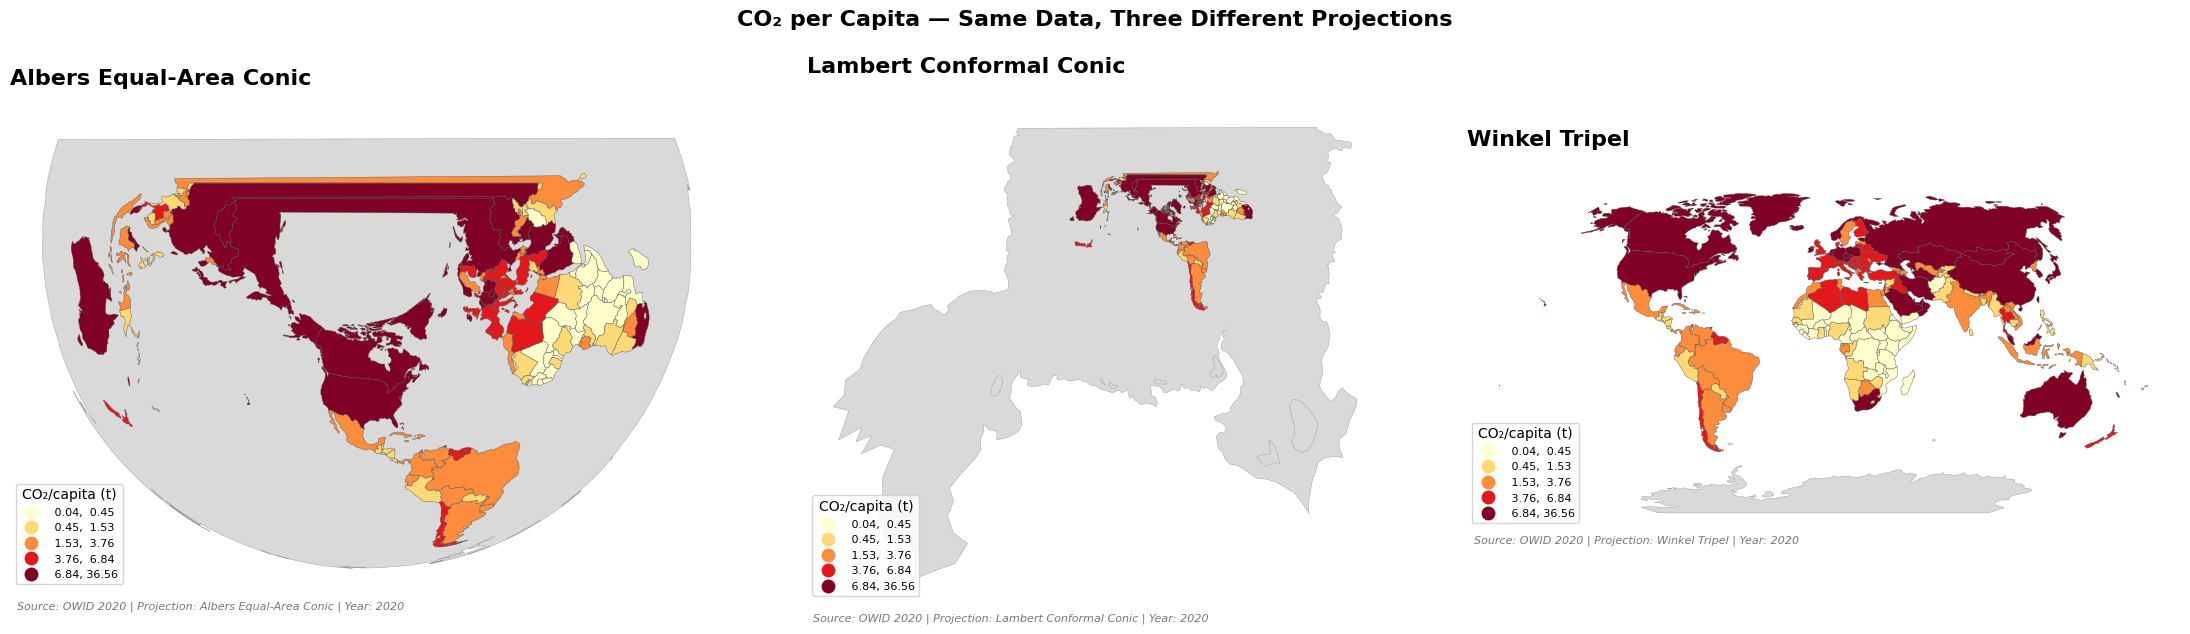

In [4]:
# ── Plot all 3 projections side by side ────────────────────
fig, axes = plt.subplots(1, 3, figsize=(22, 6))
fig.suptitle("CO₂ per Capita — Same Data, Three Different Projections",
             fontsize=16, fontweight="bold", y=1.02)

for ax, proj in zip(axes, ["albers_equal_area","lambert_conformal_conic","winkel_tripel"]):
    plot_projection(world, proj, ax=ax)

plt.tight_layout()
save_figure(fig, PATHS["fig_part1"] / "all_three_projections_comparison.png")
plt.show()

   Reprojected → albers_equal_area


   Saved: map_albers_equal_area.png  (300 DPI)


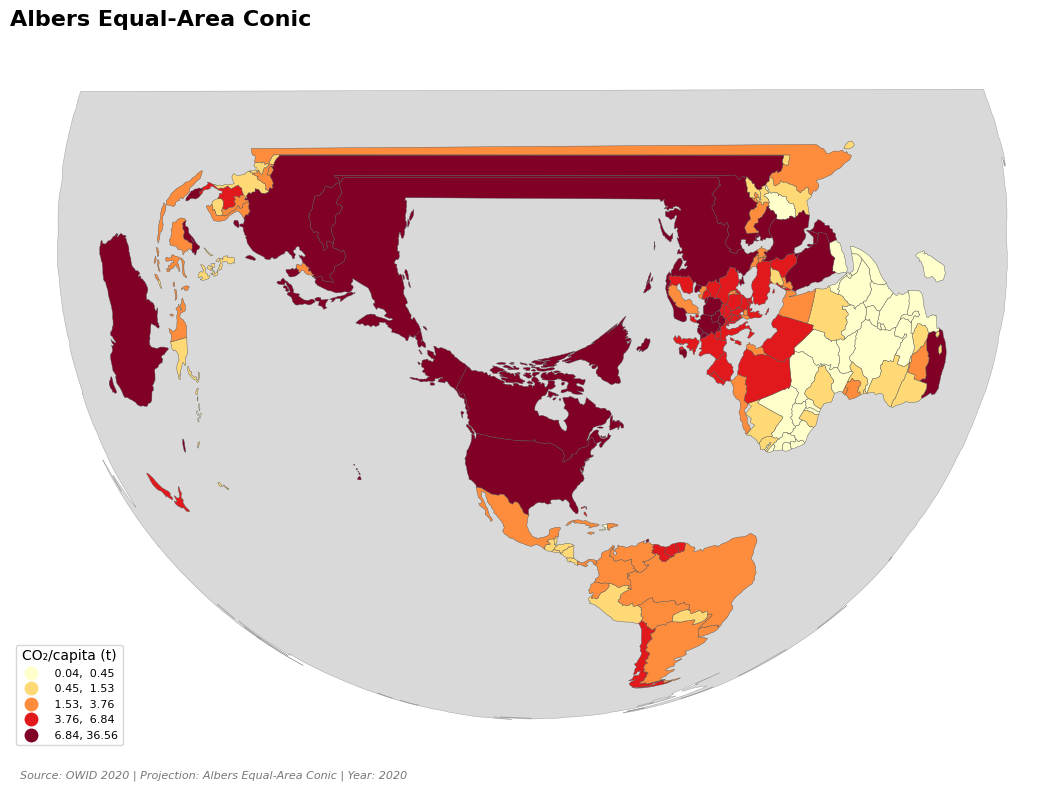

 Saved: map_albers_equal_area.png
   Reprojected → lambert_conformal_conic


   Saved: map_lambert_conformal_conic.png  (300 DPI)


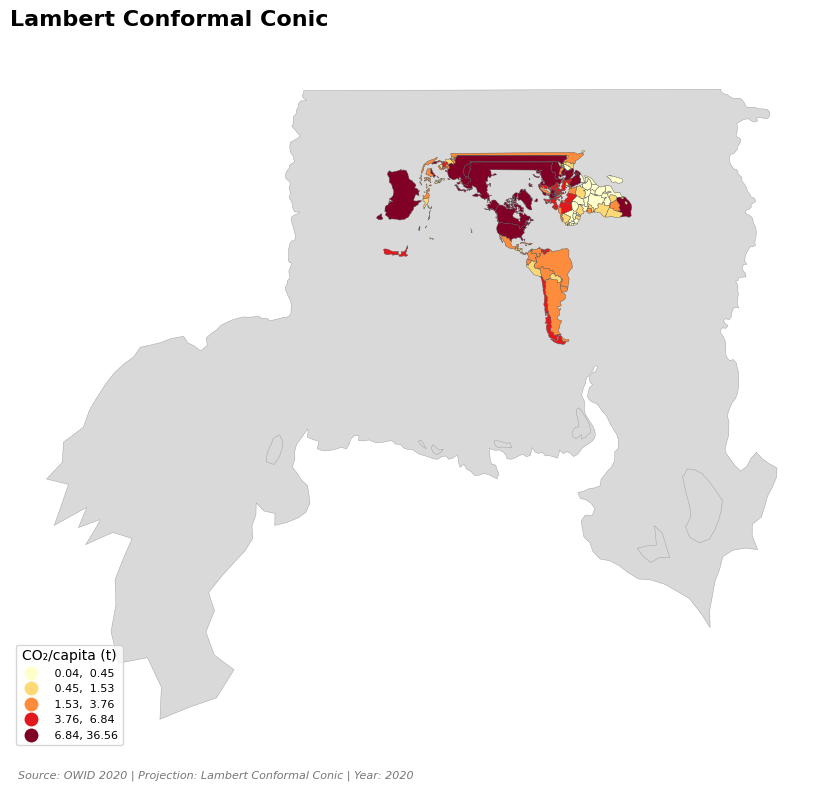

 Saved: map_lambert_conformal_conic.png
   Reprojected → winkel_tripel


   Saved: map_winkel_tripel.png  (300 DPI)


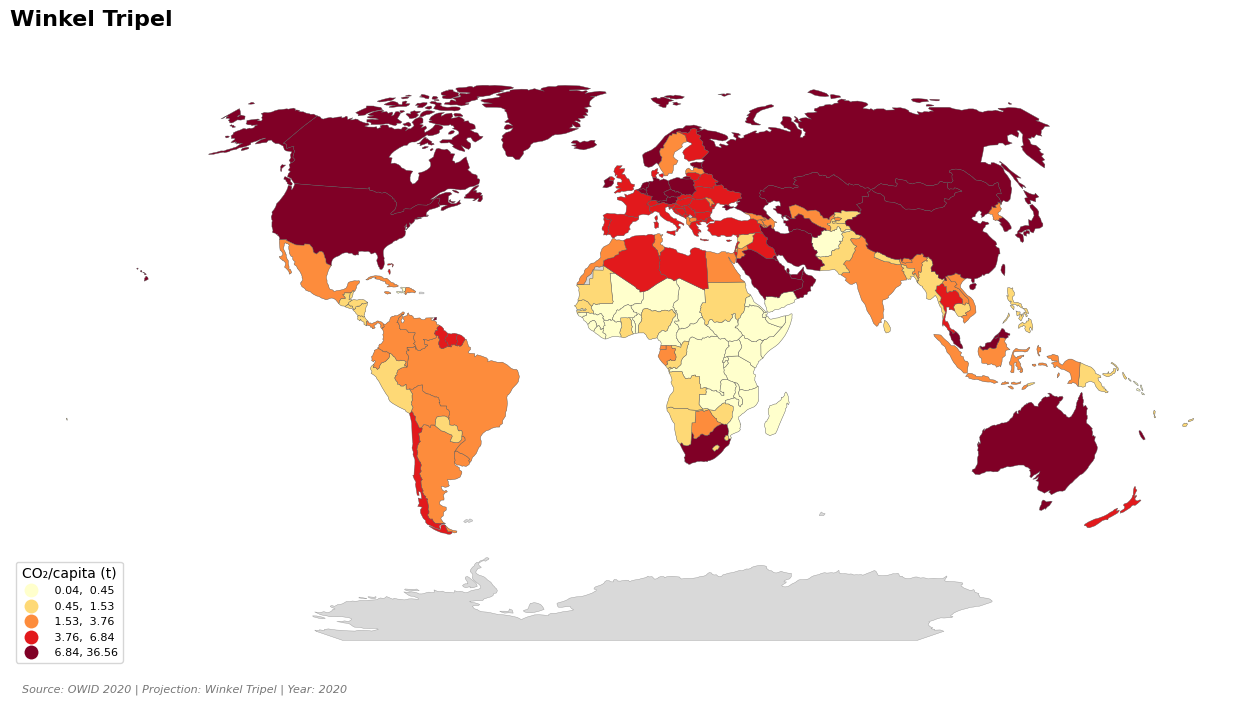

 Saved: map_winkel_tripel.png


In [5]:
# ── Individual high-res maps ───────────────────────────────
for proj_key in ["albers_equal_area","lambert_conformal_conic","winkel_tripel"]:
    fig, ax = plt.subplots(figsize=(16, 9))
    fig.patch.set_facecolor("white")
    plot_projection(world, proj_key, ax=ax)
    save_figure(fig, PATHS["fig_part1"] / f"map_{proj_key}.png")
    plt.show()
    print(f" Saved: map_{proj_key}.png")

In [6]:
# ── Projection comparison table ────────────────────────────
df = projection_comparison_table()
df["Recommended Use"] = [
    "Thematic area comparison (choropleths, regional stats)",
    "Navigation & aeronautical charts (shape preserved locally)",
    "General educational world maps (balanced distortion)"
]
df.to_csv(PATHS["fig_part1"] / "projection_comparison_table.csv", index=False)

# Display nicely in notebook
from IPython.display import display
display(df.style.set_properties(**{"text-align":"left"})
          .set_table_styles([{"selector":"th","props":[("font-weight","bold")]}]))

,Projection,Preserves,Distorts,Best For,Recommended Use
0,Albers Equal-Area Conic,Area,"Shape (at edges), direction",Thematic comparison by area,"Thematic area comparison (choropleths, regional stats)"
1,Lambert Conformal Conic,Shape (angles/conformality) locally,Area (inflated at poles),"Navigation, aeronautical charts",Navigation & aeronautical charts (shape preserved locally)
2,Winkel Tripel,Compromise — minimises overall distortion,Neither fully area nor fully conformal,General educational world maps (used by NGS),General educational world maps (balanced distortion)


   Reprojected → albers_equal_area
   Reprojected → albers_equal_area


   Reprojected → lambert_conformal_conic
   Reprojected → lambert_conformal_conic
   Reprojected → winkel_tripel
   Reprojected → winkel_tripel


   Saved: tissot_indicatrix.png  (300 DPI)


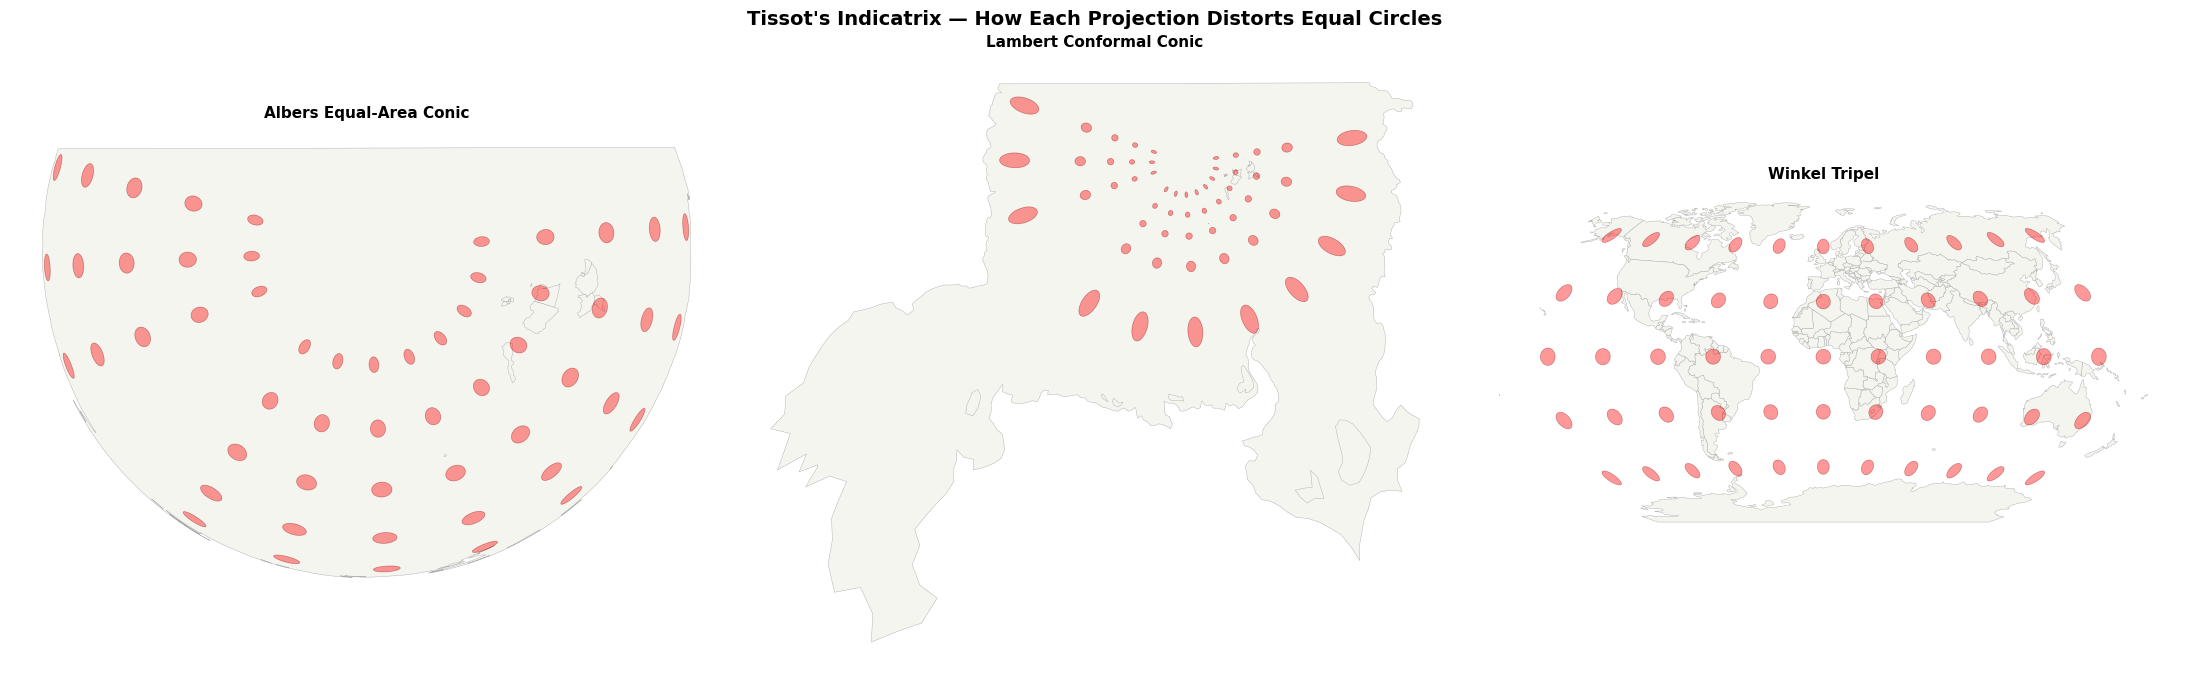

In [7]:
# ── Distortion visualisation: Tissot's Indicatrix approximation ──
# Show circles of equal size placed on the globe — they deform differently in each projection
import numpy as np
from shapely.geometry import Point
import geopandas as gpd

# Generate grid of circles in WGS84
lons = np.arange(-150, 180, 30)
lats = np.arange(-60, 90, 30)
circles = []
for lon in lons:
    for lat in lats:
        circles.append(Point(lon, lat).buffer(4))  # 4-degree radius circles

tissot = gpd.GeoDataFrame(geometry=circles, crs="EPSG:4326")

fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.suptitle("Tissot's Indicatrix — How Each Projection Distorts Equal Circles",
             fontsize=14, fontweight="bold")

for ax, proj_key in zip(axes, ["albers_equal_area","lambert_conformal_conic","winkel_tripel"]):
    world_p = reproject_gdf(world.copy(), proj_key)
    tiss_p  = reproject_gdf(tissot.copy(), proj_key)
    ax.set_facecolor(STYLE["ocean_color"])
    world_p.plot(ax=ax, color=STYLE["land_color"], linewidth=0.3, edgecolor="#aaa")
    tiss_p.plot(ax=ax, color="red", alpha=0.4, linewidth=0.5, edgecolor="darkred")
    ax.set_axis_off()
    ax.set_title(PROJECTION_LABELS[proj_key], fontsize=11, fontweight="bold")

plt.tight_layout()
save_figure(fig, PATHS["fig_part1"] / "tissot_indicatrix.png")
plt.show()

## Discussion

| Projection | Preserves | Distorts | Best For |
|---|---|---|---|
| **Albers Equal-Area** | Area | Shape at edges, direction | Thematic choropleth maps |
| **Lambert Conformal** | Local shape/angles | Area (poles inflated) | Navigation, aviation |
| **Winkel Tripel** | Compromise balance | Neither fully | General world reference maps |

**Key insight:** The Tissot indicatrix above makes distortion *visible* — in Albers the circles stay round but change size; in Lambert they stay equal but deform at high latitudes; Winkel Tripel offers the best visual balance overall.